<a href="https://colab.research.google.com/github/Jummie07/Coca/blob/main/marketing_Campaign.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_excel(r'/content/marketing_campaign_dataset.xlsx')

In [ ]:
df

,Campaign_ID,Company,Campaign_Type,Target_Audience,Duration,Channel_Used,Conversion_Rate,Acquisition_Cost,ROI,Location,Date,Clicks,Impressions,Engagement_Score,Customer_Segment
0,1,Innovate Industries,Email,Men 18-24,30 days,Google Ads,0.04,16174,6.29,Chicago,2021-01-01 00:00:00,506,1922,6,Health & Wellness
1,2,NexGen Systems,Email,Women 35-44,60 days,Google Ads,0.12,11566,5.61,New York,2021-02-01 00:00:00,116,7523,7,Fashionistas
2,3,Alpha Innovations,Influencer,Men 25-34,30 days,YouTube,0.07,10200,7.18,Los Angeles,2021-03-01 00:00:00,584,7698,1,Outdoor Adventurers
3,4,DataTech Solutions,Display,All Ages,60 days,YouTube,0.11,12724,5.55,Miami,2021-04-01 00:00:00,217,1820,7,Health & Wellness
4,5,NexGen Systems,Email,Men 25-34,15 days,YouTube,0.05,16452,6.50,Los Angeles,2021-05-01 00:00:00,379,4201,3,Health & Wellness
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200000,200001,TechCorp,Display,All Ages,30 days,Google Ads,0.06,18365,2.84,Chicago,2021-07-12 00:00:00,858,5988,1,Tech Enthusiasts
200001,200002,DataTech Solutions,Email,Men 25-34,15 days,Facebook,0.02,8168,4.14,Chicago,2021-08-12 00:00:00,228,3068,7,Foodies
200002,200003,DataTech Solutions,Social Media,Men 18-24,45 days,Website,0.05,13397,3.25,New York,2021-09-12 00:00:00,723,9548,3,Tech Enthusiasts
200003,200004,Innovate Industries,Influencer,All Ages,30 days,YouTube,0.10,18508,3.86,Houston,2021-10-12 00:00:00,528,2763,1,Foodies


**Check for missing values and inconsistencies**

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200005 entries, 0 to 200004
Data columns (total 15 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Campaign_ID       200005 non-null  int64  
 1   Company           200005 non-null  object 
 2   Campaign_Type     200005 non-null  object 
 3   Target_Audience   200005 non-null  object 
 4   Duration          200005 non-null  object 
 5   Channel_Used      200005 non-null  object 
 6   Conversion_Rate   200005 non-null  float64
 7   Acquisition_Cost  200005 non-null  int64  
 8   ROI               200005 non-null  float64
 9   Location          200005 non-null  object 
 10  Date              200005 non-null  object 
 11  Clicks            200005 non-null  int64  
 12  Impressions       200005 non-null  int64  
 13  Engagement_Score  200005 non-null  int64  
 14  Customer_Segment  200005 non-null  object 
dtypes: float64(2), int64(5), object(8)
memory usage: 22.9+ MB


In [6]:
missing_values = df.isnull().sum()
duplicates = df.duplicated().sum()
print("Missing Values:\n", missing_values)
print("Duplicate Rows:", duplicates)

Missing Values:
 Campaign_ID         0
Company             0
Campaign_Type       0
Target_Audience     0
Duration            0
Channel_Used        0
Conversion_Rate     0
Acquisition_Cost    0
ROI                 0
Location            0
Date                0
Clicks              0
Impressions         0
Engagement_Score    0
Customer_Segment    0
dtype: int64
Duplicate Rows: 0


Remove duplicates

Check for null

In [7]:
df.isna().sum()

,0
Campaign_ID,0
Company,0
Campaign_Type,0
Target_Audience,0
Duration,0
Channel_Used,0
Conversion_Rate,0
Acquisition_Cost,0
ROI,0
Location,0


Basic statistics

In [9]:
basic_stats = df.describe()
print("Basic Statistics:\n", basic_stats)

Basic Statistics:
          Campaign_ID  Conversion_Rate  Acquisition_Cost            ROI  \
count  200005.000000    200005.000000     200005.000000  200005.000000   
mean   100003.000000         0.080069      12504.441794       5.002416   
std     57736.614632         0.040602       4337.663210       1.734485   
min         1.000000         0.010000       5000.000000       2.000000   
25%     50002.000000         0.050000       8740.000000       3.500000   
50%    100003.000000         0.080000      12497.000000       5.010000   
75%    150004.000000         0.120000      16264.000000       6.510000   
max    200005.000000         0.150000      20000.000000       8.000000   

              Clicks    Impressions  Engagement_Score  
count  200005.000000  200005.000000     200005.000000  
mean      549.774591    5507.307107          5.494673  
std       260.019354    2596.863794          2.872593  
min       100.000000    1000.000000          1.000000  
25%       325.000000    3266.00000

In [10]:
print(df.columns)

Index(['Campaign_ID', 'Company', 'Campaign_Type', 'Target_Audience',
       'Duration', 'Channel_Used', 'Conversion_Rate', 'Acquisition_Cost',
       'ROI', 'Location', 'Date', 'Clicks', 'Impressions', 'Engagement_Score',
       'Customer_Segment'],
      dtype='object')


In [11]:
unique_audiences = df['Target_Audience'].dropna().unique()
unique_channels = df['Channel_Used'].dropna().unique()
print("Unique Target Audience:\n", unique_audiences)
print("Unique Channel_Used:\n", unique_channels)

Unique Target Audience:
 ['Men 18-24' 'Women 35-44' 'Men 25-34' 'All Ages' 'Women 25-34']
Unique Channel_Used:
 ['Google Ads' 'YouTube' 'Instagram' 'Website' 'Facebook' 'Email']


Use numeric columns

In [12]:
numeric_columns = ['impressions', 'clicks', 'spend', 'conversions']
plt.figure(figsize=(12, 6))
for i, col in enumerate(numeric_columns, 1):
    if col in df.columns:
        plt.subplot(2, 2, i)
        sns.boxplot(x=df[col].dropna())
        plt.title(f'Outliers in {col}')
plt.tight_layout()
plt.show()

<Figure size 1200x600 with 0 Axes>

# Insight Generation
Calculate CTR, CPC, and conversion rates

In [13]:
if 'impressions' in df.columns and 'clicks' in df.columns:
    df['Clicks'] = (df['clicks'] / df['impressions']).replace([np.inf, -np.inf], np.nan) * 100
if 'spend' in df.columns and 'clicks' in df.columns:
    df['Acquisition_Cost'] = (df['spend'] / df['clicks']).replace([np.inf, -np.inf], np.nan)
if 'conversions' in df.columns and 'clicks' in df.columns:
    df['Conversion_Rate'] = (df['conversions'] / df['clicks']).replace([np.inf, -np.inf], np.nan) * 100

Compare campaign performance across different channels

In [14]:
if {'Channel_Used', 'Clicks', 'Acquistion_Cost', 'Conversion_Rate'}.issubset(df.columns):
    channel_performance = df.groupby('Channel_Used')[['Clicks', 'Acquistion_Cost', 'Conversion_Rate']].mean().dropna()
    print("Campaign Performance by Channel_Used:\n", channel_performance)

High-performing vs. underperforming campaigns

In [15]:
if 'Conversion_Rate' in df.columns:
    roi_threshold = df['Conversion_Rate'].median()
    high_performing = df[df['Conversion_Rate'] > roi_threshold]
    low_performing = df[df['Conversion_Rate'] <= roi_threshold]

Location-based trends

In [16]:
if {'location', 'Clicks', 'Acquisition_Rate', 'Conversion_Rate'}.issubset(df.columns):
    location_trends = df.groupby('location')[['Clicks', 'Acquisition_Rate', 'Conversion_Rate']].mean().dropna()
    print("Location-based Trends:\n", location_trends)

# Data Visualization


In [17]:
plt.figure(figsize=(10, 5))

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

 Bar Chart: CTR Across Marketing Channels

In [19]:
if channel_performance is not None and not channel_performance.empty:
    sns.barplot(x=channel_performance.index, y=channel_performance['Clicks'])
    plt.title('Clicks Across Channel_Used')
    plt.ylabel('Clicks (%)')
    plt.xticks(rotation=45)
    plt.show()

NameError: name 'channel_performance' is not defined

Scatter Plot: Acquisition_Cost vs Conversion_Rate


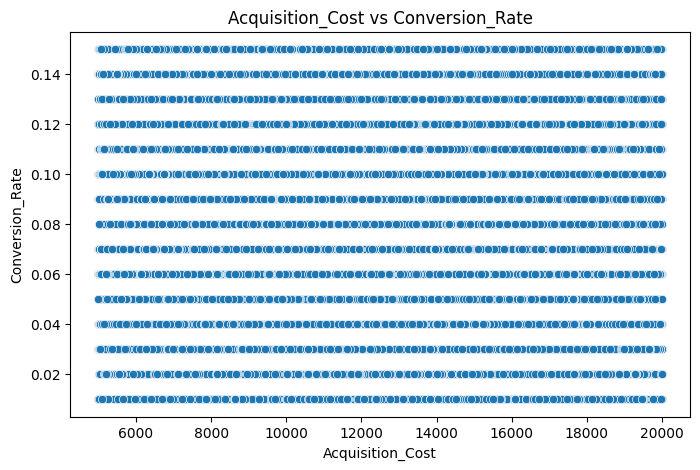

In [20]:
if 'Acquisition_Cost' in df.columns and 'Conversion_Rate' in df.columns:
    plt.figure(figsize=(8, 5))
    sns.scatterplot(x=df['Acquisition_Cost'], y=df['Conversion_Rate'])
    plt.title('Acquisition_Cost vs Conversion_Rate')
    plt.xlabel('Acquisition_Cost')
    plt.ylabel('Conversion_Rate')
    plt.show()

Pie Chart: Campaign_Type by Channels Used

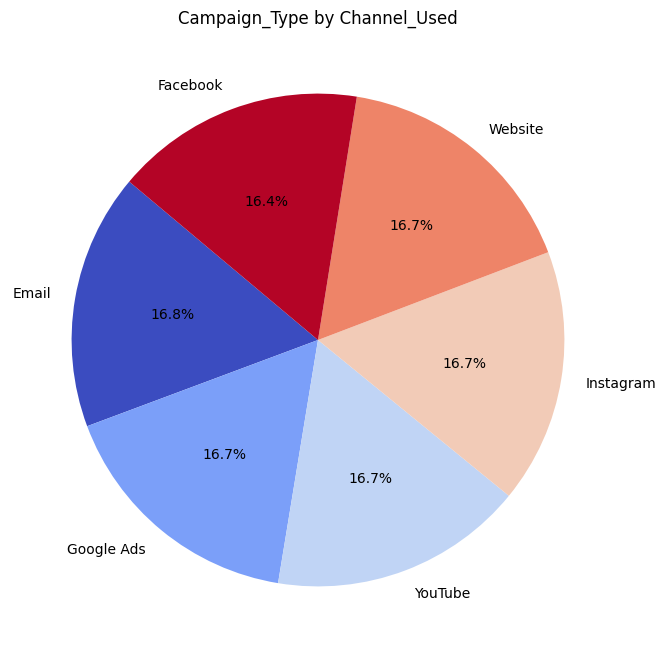

In [21]:
if 'Channel_Used' in df.columns:
    plt.figure(figsize=(8, 8))
    df['Channel_Used'].value_counts().plot.pie(autopct='%1.1f%%', startangle=140, cmap='coolwarm')
    plt.title('Campaign_Type by Channel_Used')
    plt.ylabel('')  # Hide y-label
    plt.show()


**Line Graph: CTR Trend Over Time**

In [22]:
if 'date' in df.columns and 'Clicks' in df.columns:
    df['date'] = pd.to_datetime(df['date'])
    ctr_trend = df.groupby('date')['Clicks'].mean()
    plt.figure(figsize=(10, 5))
    plt.plot(ctr_trend, marker='o', linestyle='-')
    plt.title('Clicks Trend Over Time')
    plt.xlabel('Date')
    plt.ylabel('Clicks (%)')
    plt.grid()
    plt.xticks(rotation=45)
    plt.show()

Density Plot: CPC Distribution

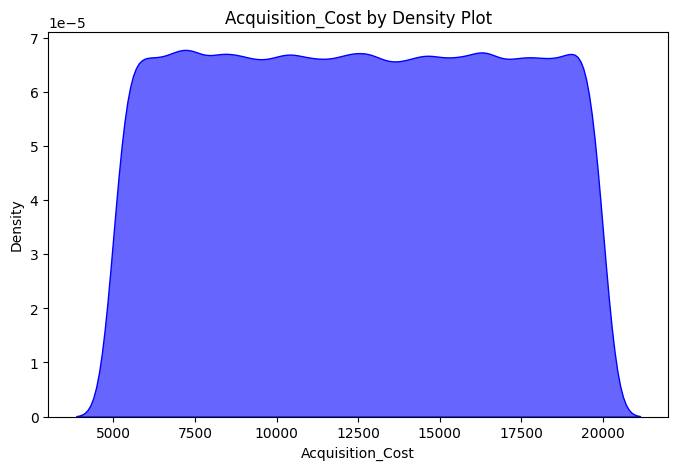

In [23]:
if 'Acquisition_Cost' in df.columns:
    plt.figure(figsize=(8, 5))
    sns.kdeplot(df['Acquisition_Cost'].dropna(), fill=True, color='blue', alpha=0.6)
    plt.title('Acquisition_Cost by Density Plot')
    plt.xlabel('Acquisition_Cost')
    plt.ylabel('Density')
    plt.show()
    df

Heatmap: Correlation Matrix

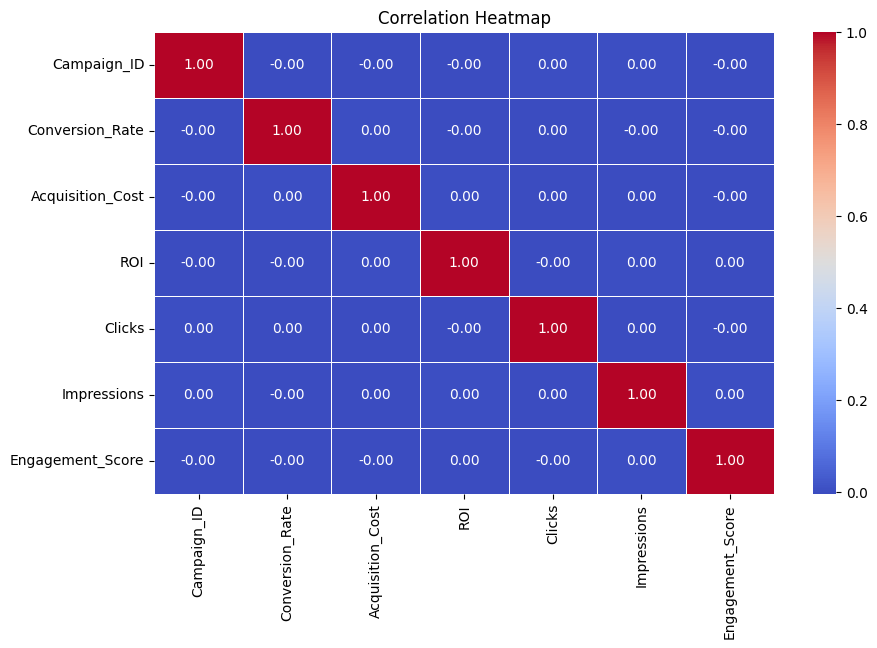

In [24]:
plt.figure(figsize=(10, 6))
corr_matrix = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

In [25]:
df.to_csv('cleaned_dataset.csv', index=False)